# 03 · Bike-Sharing — Forecasting with Covariates

## Part 3 — Forecasting *with covariates* (the payoff of exogenous data)

The financial series in `sp500-shiller` had **no covariates** — there was nothing to predict
returns *from*. Bike demand is the opposite: it is *driven* by **weather and the calendar**, and it
is **multi-seasonal** (daily + weekly). This notebook is a deep dive into forecasting that kind of
series, and it deliberately runs into — and explains — three things the textbook glosses over:

1. **Plain SARIMA cannot model hourly multi-seasonality** → we use **Fourier / dynamic harmonic
   regression** instead.
2. **Covariate availability** — using weather as a predictor secretly assumes you can *forecast the
   weather*; we'll be honest about that.
3. **The horizon decides what is leakage** — at a **24-hour-ahead** horizon, lag-24/lag-168 are
   *known*, which changes everything.

We compare four models of increasing sophistication and discover, on a built-in stress test, *why*
autoregressive memory matters.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from src import featurize as fz, forecasting as fc
from statsmodels.tsa.stattools import acf

g = data.regular_grid()                 # gapless hourly grid: cnt + weather + calendar
H = 24 * 14                             # forecast horizon / test window = last 14 days
y = g["cnt"]
tr, te = slice(0, len(g) - H), slice(len(g) - H, len(g))
print("grid:", g.shape, "| test window:", g.index[-H].date(), "->", g.index[-1].date())

setup ok | numpy 2.1.3 | pandas 2.3.3


grid: (17544, 23) | test window: 2012-12-18 -> 2012-12-31


### 1. The task, the split, and a crucial subtlety

**Task:** forecast hourly `cnt` for the **last 14 days**, evaluated with **MASE** (vs the in-sample
*weekly* naive) and **RMSE**.

**The 24-hour-ahead framing.** We imagine running each morning: predict the next 24 hours using
everything observed through the previous midnight. Why it matters: for a 24h-ahead forecast, **any
lag of ≥24 hours is already observed** — so `lag24` (same hour yesterday) and `lag168` (same hour
last week) are *legitimate, leakage-free* regressors with **no recursion**. (A longer horizon would
force recursion and error would compound.)

**The covariate-availability caveat.** Using `temp`, `hum`, `wind` as predictors assumes we *know*
the future weather. In production you'd plug in a **weather forecast** (itself uncertain); here we
use the recorded actuals — a "perfect-foresight" assumption that flatters the weather models. The
**calendar** (hour, day, month, holiday) is genuinely known in advance.

**The built-in stress test.** Note the test window below — it is the **Christmas / New-Year
holidays**, when demand behaves nothing like a normal December. That is not a mistake; it is the
most revealing fortnight in the dataset.

In [2]:
print("test window mean cnt = %.0f  vs  2012 overall = %.0f  -> holiday demand collapses to ~half"
      % (y[te].mean(), y[g.index.year == 2012].mean()))
def score(p): r = fc.forecast_metrics(y[te].values, np.clip(p, 0, None), y[tr].values, 168); return r["MASE"], r["RMSE"]

test window mean cnt = 106  vs  2012 overall = 234  -> holiday demand collapses to ~half


### 2. Baseline — the weekly seasonal naive

For a strongly weekly series the bar to beat is **"same hour last week"** (`ŷₜ = yₜ₋₁₆₈`). Any
model that can't beat this earns nothing.

In [3]:
naive = y.shift(168).values[te]
mase_n, rmse_n = score(naive)
print("seasonal-naive (lag 168):  MASE %.3f  RMSE %.1f" % (mase_n, rmse_n))

seasonal-naive (lag 168):  MASE 1.656  RMSE 141.6


### 3. Why not plain SARIMA? — and the Fourier fix

**SARIMA(p,d,q)(P,D,Q)ₘ models ONE seasonal period `m`.** Hourly demand has *two* strong ones
(daily 24, weekly 168). You cannot put both in `seasonal_order`, and a seasonal term at lag 168 on
17,000 points is computationally hopeless (the state-space blows up; in testing it simply fails to
converge).

**The standard fix is dynamic harmonic regression:** represent each seasonal cycle by a handful of
**Fourier terms** — sine/cosine pairs at harmonics of the seasonal frequency — and feed them as
*regressors*. `K` harmonics give `2K` smooth basis functions; more `K` = a sharper seasonal shape.
A short ARIMA can then model whatever autocorrelation is left. Here are the daily Fourier terms
reconstructing the commute shape:

Fourier design: 20 daily + 10 weekly columns


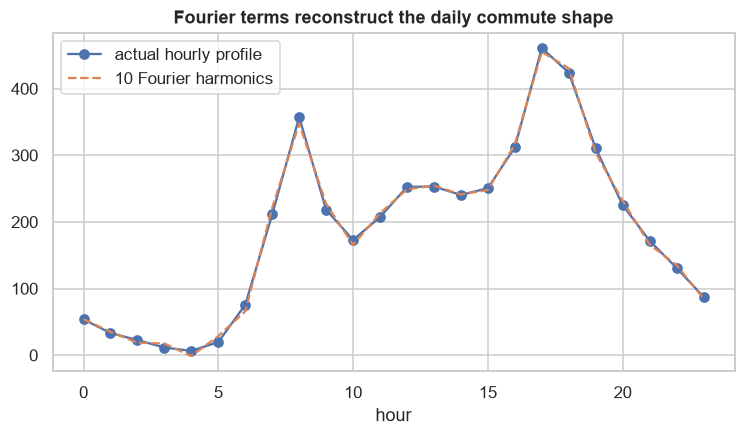

In [4]:
F24 = fz.fourier_terms(g.index, 24, 10)     # 10 daily harmonics
F168 = fz.fourier_terms(g.index, 168, 5)    # 5 weekly harmonics
print("Fourier design: %d daily + %d weekly columns" % (F24.shape[1], F168.shape[1]))
# Show that a few harmonics already trace one day's average demand profile
prof = y.groupby(g.index.hour).mean()
fitday = LinearRegression().fit(F24.iloc[:24].values, prof.values).predict(F24.iloc[:24].values)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prof.index, prof.values, "o-", label="actual hourly profile")
ax.plot(prof.index, fitday, "--", label="10 Fourier harmonics"); ax.legend()
ax.set_title("Fourier terms reconstruct the daily commute shape"); ax.set_xlabel("hour")
eda.savefig(fig, "p3_fourier.png"); plt.show()

### 4. Model A — harmonic regression + weather (the classical covariate model)

Regress `cnt` on the Fourier seasonality **plus the exogenous weather/calendar regressors**
(`temp`, `hum`, `wind`, `workingday`, `holiday`). The weather coefficients are the **exogenous
effect** — how demand moves with conditions, holding the time-of-week pattern fixed. It has **no
autoregressive memory**, so remember that for the stress test.

In [5]:
exog = pd.concat([F24, F168, g[["temp_C", "hum_pct", "wind_kmh", "workingday", "holiday"]]], axis=1)
harm = LinearRegression().fit(exog.values[tr], y.values[tr])
pred_harm = harm.predict(exog.values[te])
mase_h, rmse_h = score(pred_harm)
print("harmonic + weather:  MASE %.3f  RMSE %.1f" % (mase_h, rmse_h))
coef = pd.Series(harm.coef_, index=exog.columns)
print("\nexogenous effects (per unit):")
print("  +1°C temp      -> %+6.1f rentals/hr" % coef["temp_C"])
print("  +10%% humidity  -> %+6.1f rentals/hr" % (10 * coef["hum_pct"]))
print("  +10 km/h wind  -> %+6.1f rentals/hr" % (10 * coef["wind_kmh"]))
print("  working day    -> %+6.1f rentals/hr" % coef["workingday"])

harmonic + weather:  MASE 1.263  RMSE 99.4

exogenous effects (per unit):
  +1°C temp      ->   +6.9 rentals/hr
  +10% humidity  ->  -12.3 rentals/hr
  +10 km/h wind  ->  -11.9 rentals/hr
  working day    ->  +28.6 rentals/hr


It beats the naive — the **weather signal is real** (warmth lifts demand, humidity and wind
suppress it). But a linear model can't express *interactions* (the commute peak exists **only** on
working days), which is where trees come in.

### 5. Models B & C — gradient-boosted trees

**B — calendar + weather (no lags).** LightGBM captures **nonlinear interactions** (hour ×
workingday, the temperature curve) that the linear model can't. But it still has no memory of
*recent* demand.

In [6]:
mdl_cal = lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
mdl_cal.fit(g[fz.CALENDAR + fz.WEATHER].values[tr], y.values[tr])
pred_cal = mdl_cal.predict(g[fz.CALENDAR + fz.WEATHER].values[te])
mase_c, rmse_c = score(pred_cal)
print("LGBM calendar+weather:  MASE %.3f  RMSE %.1f" % (mase_c, rmse_c))

LGBM calendar+weather:  MASE 1.068  RMSE 84.9


C:\Users\parth\practice-eda\bike-sharing\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**C — add autoregressive lags.** Now add `lag24`, `lag168`, `roll24` (all ≥24h → known at a
24h-ahead horizon, no leakage). These carry the **recent level** of demand — and that turns out to
be the single most important thing.

In [7]:
gl = fz.add_lags(g)
cols = fz.CALENDAR + fz.WEATHER + fz.LAG_COLS
mdl_lag = lgb.LGBMRegressor(n_estimators=700, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
mdl_lag.fit(gl[cols].iloc[168:len(g) - H], y.values[168:len(g) - H])
pred_lag = mdl_lag.predict(gl[cols].values[te])
mase_l, rmse_l = score(pred_lag)
print("LGBM + lags (24h-ahead): MASE %.3f  RMSE %.1f" % (mase_l, rmse_l))
imp = pd.Series(mdl_lag.feature_importances_, index=cols).sort_values(ascending=False)
print("\ntop features:", list(imp.head(6).index))

LGBM + lags (24h-ahead): MASE 0.611  RMSE 55.8

top features: ['lag168', 'lag24', 'roll24', 'hr', 'hum_pct', 'temp_C']


C:\Users\parth\practice-eda\bike-sharing\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 6. Scoreboard

In [8]:
board = pd.DataFrame({
    "seasonal-naive":      [mase_n, rmse_n],
    "harmonic+weather":    [mase_h, rmse_h],
    "LGBM calendar+weather":[mase_c, rmse_c],
    "LGBM + lags":         [mase_l, rmse_l],
}, index=["MASE", "RMSE"]).T.sort_values("MASE")
print(board.round(3).to_string())

                        MASE     RMSE
LGBM + lags            0.611   55.827
LGBM calendar+weather  1.068   84.888
harmonic+weather       1.263   99.378
seasonal-naive         1.656  141.576


The ranking is the lesson. **Lags win decisively** (MASE ≈ 0.61 — well under the 1.66 naive and
less than half its RMSE). Harmonic+weather beats the naive on *seasonality + weather*; the calendar
tree improves on it with nonlinearity but still trails the lag model — *nonlinearity without memory
isn't enough*. To see *why* the lag model dominates, look at the holiday week.

### 7. The holiday stress test — why memory matters

Plot the forecasts over the final days. Demand **collapses** for Christmas and New Year. The
seasonal/calendar/harmonic models predict a **normal December** and badly over-predict — they have
no way to know a holiday lull is underway (with only ~2 years of data they've barely seen these
dates). The **lag model follows the drop**, because `lag24`/`lag168` carry yesterday's and last
week's already-collapsed demand.

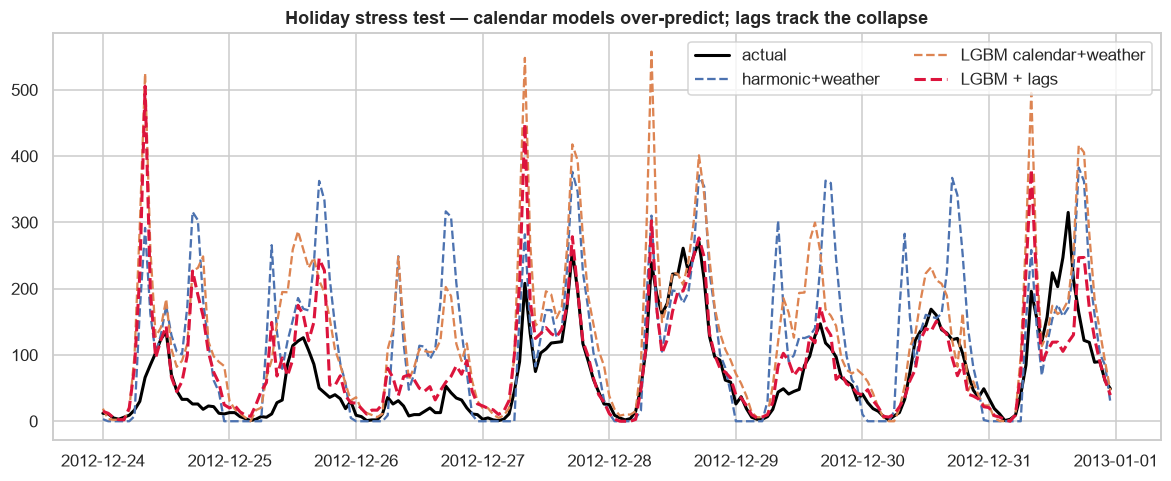

Dec 25 mean:  actual 42 | harmonic 118 (over) | LGBM+lags 83


In [9]:
days = slice(len(g) - 24 * 8, len(g))      # last 8 days
idx = g.index[days]
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(idx, y.values[days], color="black", lw=2, label="actual")
ax.plot(idx, np.clip(pred_harm, 0, None)[-24*8:], "--", label="harmonic+weather")
ax.plot(idx, np.clip(pred_cal, 0, None)[-24*8:], "--", label="LGBM calendar+weather")
ax.plot(idx, np.clip(pred_lag, 0, None)[-24*8:], "--", color="crimson", lw=2, label="LGBM + lags")
ax.set_title("Holiday stress test — calendar models over-predict; lags track the collapse"); ax.legend(ncol=2)
eda.savefig(fig, "p3_holiday.png"); plt.show()
xmas = (g.index[te].normalize() == pd.Timestamp("2012-12-25"))
print("Dec 25 mean:  actual %.0f | harmonic %.0f (over) | LGBM+lags %.0f"
      % (y[te][xmas].mean(), np.clip(pred_harm,0,None)[xmas].mean(), np.clip(pred_lag,0,None)[xmas].mean()))

### 8. What drives the winning model? — feature importance

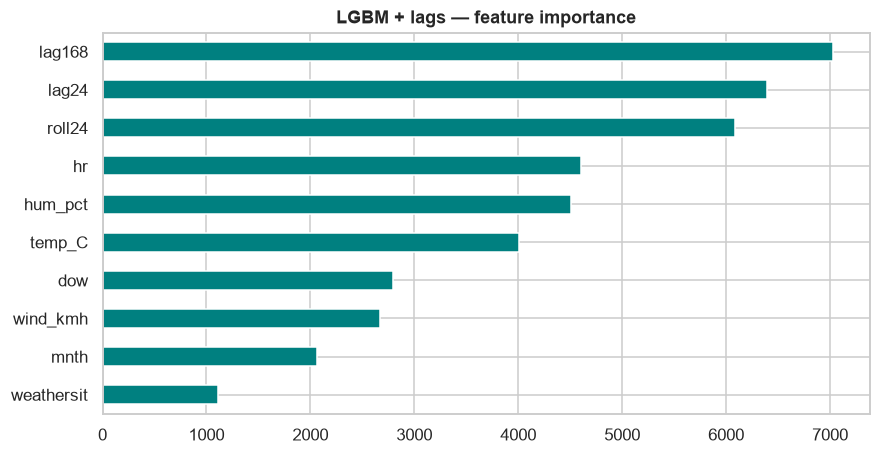

Recent demand (lag168, roll24, lag24) dominates, then weather (hum, temp) and hour.


In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
imp.head(10)[::-1].plot.barh(ax=ax, color="teal"); ax.set_title("LGBM + lags — feature importance")
eda.savefig(fig, "p3_importance.png"); plt.show()
print("Recent demand (lag168, roll24, lag24) dominates, then weather (hum, temp) and hour.")

### 9. Honest uncertainty — a conformal interval

A point forecast hides risk. We build a **distribution-free conformal** interval: train on data up
to 28 days before the end, measure absolute residuals on the next 14 days (**calibration**), take
their 90% quantile as the band radius, and apply it to the final 14-day forecast — then check the
empirical coverage.

In [11]:
cal = slice(len(g) - 2 * H, len(g) - H)
m_cal = lgb.LGBMRegressor(n_estimators=700, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
m_cal.fit(gl[cols].iloc[168:len(g) - 2 * H], y.values[168:len(g) - 2 * H])
resid = np.abs(y.values[cal] - np.clip(m_cal.predict(gl[cols].values[cal]), 0, None))
q = np.quantile(resid, 0.90)
lo, hi = np.clip(pred_lag - q, 0, None), pred_lag + q
cov = ((y.values[te] >= lo) & (y.values[te] <= hi)).mean()
print("conformal 90%% band: ±%.0f rentals | empirical coverage %.0f%%" % (q, 100 * cov))

conformal 90% band: ±78 rentals | empirical coverage 90%


C:\Users\parth\practice-eda\bike-sharing\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 10. Takeaways

- With **exogenous drivers**, forecasting becomes a *covariate* problem — but the **horizon defines
  leakage**: at 24h-ahead, `lag≥24` features are known and dominate.
- **SARIMA can't do hourly multi-seasonality** → use **Fourier / dynamic harmonic regression**;
  `K` harmonics trade smoothness for sharpness.
- **Weather is a genuine signal** (warmth ↑, humidity/wind ↓ demand), but a linear model misses the
  **hour × workingday interaction** that trees capture for free.
- **Autoregressive memory wins** (MASE ≈ 0.61 vs the 1.66 naive): recent demand is the strongest
  predictor — *especially* through the **holiday collapse**, where calendar/seasonal models
  over-predict (Christmas Day: harmonic 118 vs actual 42) because they've never learned the date.
- Be honest about **covariate availability** (you'd need a weather *forecast*) and pair every point
  forecast with an **interval** (conformal coverage ≈ 90%).

**Where next:** a full **walk-forward backtest** across many windows (not just the holidays), a
**log/Poisson** treatment of the count target, and **probabilistic** gradient boosting — or fold
these models into an operational daily-refit pipeline.